# LIMIT: Hybrid IR Analysis, Ablations, and Insights

This notebook demonstrates the complete experiment workflow for the LIMIT project:
- Theoretical context and motivation
- Data loading and configuration
- Baseline hybrid retrieval (BM25 + SPLADE + Dense) with cross-encoder reranking
- Fusion strategy comparisons (weighted sum vs RRF; different normalizers)
- Embedding-dimension ablation experiments and plots
- Query planning (optional): LLM decomposition and candidate merging
- Error analysis and conclusions

## 1. Theoretical Framework Understanding

### Google's LIMIT Paper: Mathematical Proof of Embedding Limitations

**Core Theorem:** For any fixed embedding dimension $d$, there exists a corpus size $n$ and query set such that no bi-encoder (separate query/document embeddings) can achieve perfect retrieval.

**Proof Sketch:**
- Consider a corpus with $n$ documents embedded in $\mathbb{R}^d$
- Each query needs to retrieve a specific subset of 2 documents (LIMIT's design)
- The number of possible document pairs grows as $\binom{n}{2} = O(n^2)$
- But the number of distinguishable query embeddings (with bounded precision) is roughly $O(2^d)$
- When $n^2 > 2^d$, there aren't enough unique query vectors to represent all possible pair retrievals
- Therefore, some document pairs cannot be reliably retrieved by any single query vector

### Combinatorial Design: Why Exactly 2 Relevant Documents?

The LIMIT dataset uses **exactly 2 relevant documents per query** to create the theoretical impossibility:

- **Binary relevance**: Each query has qrels with exactly 2 document IDs marked as relevant
- **Combinatorial stress**: With $n$ documents, there are $\binom{n}{2}$ possible pairs
- **Embedding capacity**: A $d$-dimensional embedding space can only distinguish a finite number of regions
- **Failure guarantee**: When corpus size exceeds embedding capacity, collisions are inevitable

**Example:** With $d=768$ and $n=10,000$ documents:
- Possible pairs: $\binom{10000}{2} = 49,995,000$
- Embedding capacity: $\approx 2^{768}$ (extremely large, but finite with discretization)
- In practice, documents cluster in semantic space, reducing effective capacity dramatically

### Qrels Structure: Encoding Impossibility Scenarios

LIMIT's qrels (relevance judgments) encode these theoretical constraints:

```json
{"query-id": "q1", "corpus-id": "doc_42", "score": 1}
{"query-id": "q1", "corpus-id": "doc_137", "score": 1}
```

Each query maps to exactly 2 documents that may be:
- Semantically similar (easy case - single vector can handle)
- Semantically diverse (hard case - single vector must compromise position)
- Lexically overlapping but semantically different (exposes keyword vs. semantic trade-offs)

### Why Single-Vector Embeddings Fail: Mathematical Intuition

**Geometric Constraint:** A query vector $\vec{q} \in \mathbb{R}^d$ retrieves documents by cosine similarity:
$$\text{score}(q, d_i) = \frac{\vec{q} \cdot \vec{d_i}}{||\vec{q}|| \cdot ||\vec{d_i}||}$$

**The Problem:** To retrieve both $d_1$ and $d_2$ with high scores:
- Need $\vec{q}$ close to both $\vec{d_1}$ and $\vec{d_2}$
- If $\vec{d_1}$ and $\vec{d_2}$ are far apart (low $\vec{d_1} \cdot \vec{d_2}$), no single $\vec{q}$ can be close to both
- The query vector must compromise, potentially missing one or both documents

**Visualization:** In 2D space, if doc1 is at (1,0) and doc2 is at (0,1), the optimal query is at (0.707, 0.707), giving similarity ≈0.707 to each. But a third document at (0.71, 0.70) might score higher, causing retrieval failure.

---

## 2. Implementation Analysis

### Hybrid Approach: Overcoming Single-Vector Limitations

**Why BM25 + SPLADE + Dense?**

Each retriever provides **complementary signals** that overcome different failure modes:

1. **BM25 (Lexical)**:
   - Exact term matching, no semantic understanding
   - Immune to embedding dimension limitations
   - Fails on synonym/paraphrase queries

2. **SPLADE (Sparse Learned)**:
   - Vocabulary-sized sparse vectors (~30k dims)
   - Learns term importance through neural training
   - Bridges keyword and semantic matching

3. **Dense (Single-Vector Semantic)**:
   - Captures semantic similarity in 768 dims
   - Subject to LIMIT's theoretical constraints
   - Excels at paraphrase/synonym queries

**Complementarity:** When one retriever fails on a query, others may succeed, increasing overall Recall.

### Cross-Encoder Reranking: Escaping Single-Vector Constraints

**How it works:**
- Encodes `[query, document]` pairs jointly: `BERT([CLS] query [SEP] doc [SEP])`
- Full self-attention between query and document tokens
- Output: single relevance score per pair

**Why it overcomes limitations:**
- Not constrained by separate embeddings
- Can capture arbitrary query-document interactions
- Computational cost: $O(n)$ forward passes (hence two-stage retrieval)

**Trade-off:** 
- Retrieval: Fast ($O(1)$ with pre-computed doc embeddings), lower quality
- Reranking: Slow ($O(n)$), higher quality
- **Solution:** Hybrid retrieves 500 candidates, rerank top 200

### Ablation Studies: Why Embedding Dimension Matters

**Research Question:** How does reducing $d$ (embedding dimension) affect retrieval quality?

**Hypothesis (from LIMIT theory):**
- Smaller $d$ → fewer distinguishable regions in embedding space
- Fewer regions → more document pairs map to same query vector
- More collisions → lower Recall@k and nDCG@k

**Our Ablation:**
- Truncate embeddings: `emb[:d]` for $d \in \{32, 64, 128, 256, 512, 768\}$
- Measure Recall@10, nDCG@10 at each dimension
- **Both** query and document embeddings truncated (critical for valid results)

**Expected Results:**
- Performance degrades as $d$ decreases
- Diminishing returns beyond some threshold (e.g., 512)
- BM25 unaffected (no embeddings)

## Environment Setup

Make sure dependencies are installed (numpy, rank-bm25, sentence-transformers, transformers, torch). If running locally, install via project metadata (pyproject.toml).

In [1]:
# Python imports and notebook setup
import os, sys, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the project root directory (where pyproject.toml is located)
nb_dir = Path.cwd()
project_root = nb_dir
while not (project_root / 'pyproject.toml').exists() and project_root.parent != project_root:
    project_root = project_root.parent

print('Current directory:', nb_dir)
print('Project root found at:', project_root)

# Add project root to Python path for imports
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print('Added to Python path:', project_root)

# Change to project root for relative file paths
os.chdir(project_root)
print('Working directory set to:', os.getcwd())

# Plot defaults
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

Current directory: /home/iluha/projects/limit/src/notebooks
Project root found at: /home/iluha/projects/limit
Added to Python path: /home/iluha/projects/limit
Working directory set to: /home/iluha/projects/limit


In [2]:
nb_dir

PosixPath('/home/iluha/projects/limit/src/notebooks')

In [3]:
# Load configuration and data
import yaml
from src.utils.data_loader import load_corpus_queries_qrels

with open('src/config/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

corpus, queries, qrels = load_corpus_queries_qrels(config)
len(corpus), len(queries), len(qrels)

[2025-12-04 09:41:20,593] INFO - Loading jsonl from src/data/corpus-small.jsonl
[2025-12-04 09:41:20,594] INFO - Loading jsonl from src/data/queries-small.jsonl
[2025-12-04 09:41:20,597] INFO - Loading jsonl from src/data/qrels-small.jsonl
[2025-12-04 09:41:20,604] INFO - Normalizing corpus documents (ensure id/text)
[2025-12-04 09:41:20,604] INFO - Normalizing qrels into mapping (qid -> list of doc ids)
[2025-12-04 09:41:20,606] INFO - Loaded 46 corpus docs, 1000 queries, 1000 qrel entries


(46, 1000, 1000)

## Build Models and Pipeline

We instantiate BM25, SPLADE, and Dense retrievers plus a cross-encoder reranker. Optionally, enable a late interaction (multi-vector) retriever and query planning in the config.

In [4]:
# Instantiate models based on config
try:
    from src.models.bm25 import BM25Retriever
    from src.models.splade import SPLADERetriever
    from src.models.dense import DenseRetriever
    from src.models.reranker import CrossEncoderReranker
    from src.experiments.baseline_experiment import BaselineExperiment
    print("✅ All core modules imported successfully")
except ImportError as e:
    print(f" Import error: {e}")
    print("\nTo fix this, run in terminal:")
    print("cd /home/iluha/projects/limit")
    print("source .venv/bin/activate") 
    print("pip install -e .")
    raise

bm25 = BM25Retriever(corpus)
splade = SPLADERetriever(config['models']['splade'])
dense = DenseRetriever(config['models']['dense'])
reranker = CrossEncoderReranker(config['models']['reranker'])
retrievers = [bm25, splade, dense]

# Optionally enable late interaction retriever
if config.get('models', {}).get('late_interaction'):
    try:
        from src.models.late_interaction import LateInteractionRetriever
        li = LateInteractionRetriever(config['models']['late_interaction'])
        retrievers.append(li)
        print('✅ Late interaction retriever enabled')
    except Exception as e:
        print(f'⚠️  Failed to init late interaction retriever: {e}')

experiment = BaselineExperiment(retrievers, reranker, corpus, queries, qrels, config)
print(f"✅ Experiment ready with {len(retrievers)} retrievers")

/home/iluha/projects/limit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All core modules imported successfully
✅ Experiment ready with 3 retrievers


## Baseline Run (subset)

Run a small subset to verify everything works and preview metrics. Adjust `N_QUERIES` and config `top_k`/`rerank_k` for speed.

In [5]:
# Optional: limit to a subset of queries for a quick pass
N_QUERIES = 5  # change to None to run all

orig_queries = queries
if N_QUERIES is not None:
    queries = queries[:N_QUERIES]
    experiment.queries = queries

results = experiment.run()
# Aggregate metrics
recall10 = []
ndcg10 = []
for qid, m in results.items():
    recall10.append(m.get('recall@10', 0.0))
    ndcg10.append(m.get('nDCG@10', 0.0))

summary = {
    'count': len(results),
    'mean_recall@10': float(np.mean(recall10)) if recall10 else 0.0,
    'mean_nDCG@10': float(np.mean(ndcg10)) if ndcg10 else 0.0,
}
summary

Device set to use cuda:0
[2025-12-04 09:42:10,782] INFO - Query planning enabled with model=google/flan-t5-small
[2025-12-04 09:42:11,773] INFO - Decomposed into 3 sub-queries
/home/iluha/projects/limit/src/models/reranker.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device != "cpu")):
[2025-12-04 09:42:36,733] INFO - Query query_0: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'])
[2025-12-04 09:42:36,733] INFO - Query query_0: intersection size=2
[2025-12-04 09:42:36,992] INFO - Decomposed into 3 sub-queries
[2025-12-04 09:43:01,446] INFO - Query query_1: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Aliza Uhlrich', 'Cristy Walford', 'Eustace Comment', 'Gladstone Oonk', 'Darwyn Raio',

{'count': 5, 'mean_recall@10': 0.4, 'mean_nDCG@10': 0.15339203895297865}

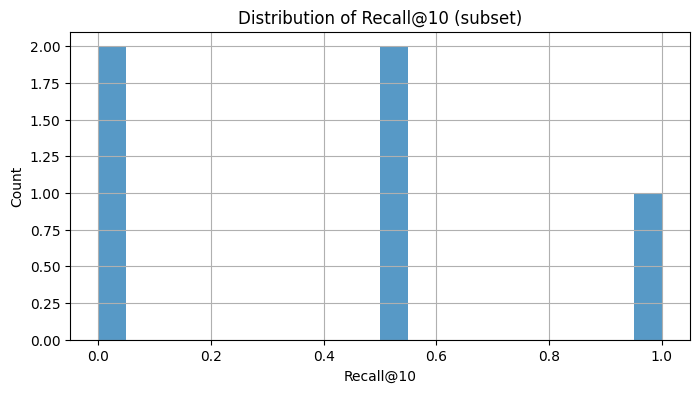

In [6]:
# Plot distribution of Recall@10 across queries
plt.figure()
plt.hist(recall10, bins=20, alpha=0.75)
plt.title('Distribution of Recall@10 (subset)')
plt.xlabel('Recall@10')
plt.ylabel('Count')
plt.show()

## Fusion Strategy Comparison

We compare weighted-minmax vs RRF (rank fusion). For speed, we reuse loaded data and only change fusion settings in a copied config.

In [7]:
import copy
from src.retrieval.hybrid_retriever import HybridRetrievalPipeline

def run_with_fusion(cfg, queries, label):
    bm25 = BM25Retriever(corpus)
    splade = SPLADERetriever(cfg['models']['splade'])
    dense = DenseRetriever(cfg['models']['dense'])
    rr = CrossEncoderReranker(cfg['models']['reranker'])
    exp = BaselineExperiment([bm25, splade, dense], rr, corpus, queries, qrels, cfg)
    res = exp.run()
    vals = [v.get('recall@10', 0.0) for v in res.values()]
    return label, float(np.mean(vals)) if vals else 0.0

cfg1 = copy.deepcopy(config)
cfg1['retriever']['fusion'] = 'weighted'
cfg1['retriever']['normalizer'] = 'minmax'
cfg2 = copy.deepcopy(config)
cfg2['retriever']['fusion'] = 'rrf'
labels, means = [], []
for lbl, cfgx in [('weighted+minmax', cfg1), ('rrf', cfg2)]:
    l, m = run_with_fusion(cfgx, queries, lbl)
    labels.append(l); means.append(m)
pd.DataFrame({'fusion': labels, 'mean_recall@10': means})

Device set to use cuda:0
[2025-12-04 09:44:22,869] INFO - Query planning enabled with model=google/flan-t5-small
[2025-12-04 09:44:23,129] INFO - Decomposed into 3 sub-queries
[2025-12-04 09:44:48,244] INFO - Query query_0: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'])
[2025-12-04 09:44:48,245] INFO - Query query_0: intersection size=2
[2025-12-04 09:44:48,521] INFO - Decomposed into 3 sub-queries
[2025-12-04 09:45:12,549] INFO - Query query_1: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Aliza Uhlrich', 'Cristy Walford', 'Eustace Comment', 'Gladstone Oonk', 'Darwyn Raio', 'Ovid Rahm', 'Armand Schweda', 'Sheree Riddley'])
[2025-12-04 09:45:12,549] INFO - Query query_1: intersection size=2
[2025-12-04 09:45:12,783] INFO - Decomposed into 3 sub-queries
[2025-12-04 09:45:36,467] INFO - Query query_2: retrieved 4

,fusion,mean_recall@10
0,weighted+minmax,0.4
1,rrf,0.4


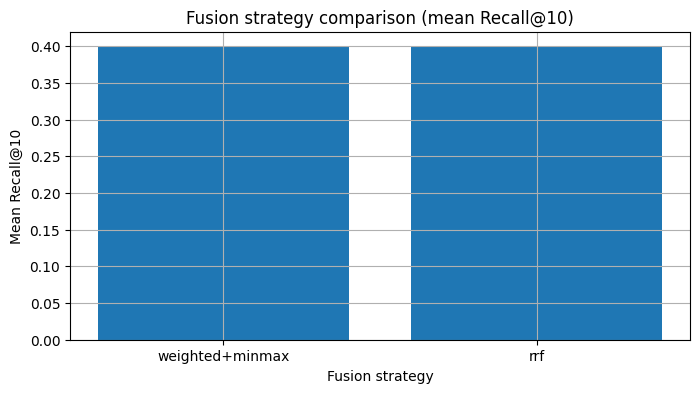

In [8]:
# Plot fusion comparison
df = pd.DataFrame({'fusion': labels, 'mean_recall@10': means})
plt.figure()
plt.bar(df['fusion'], df['mean_recall@10'])
plt.title('Fusion strategy comparison (mean Recall@10)')
plt.xlabel('Fusion strategy')
plt.ylabel('Mean Recall@10')
plt.show()

## Ablation Over Embedding Dimensions

We reuse the built-in ablation harness. It trims/pads embeddings and measures Recall@2/10/100 and nDCG@10. Results are saved under `runs/`.

In [9]:
# Run ablation (uses config['ablation'])
abl_rows = experiment.run_ablation(config)
(abl_rows[:3] if isinstance(abl_rows, list) else abl_rows)

[2025-12-04 09:48:40,573] INFO - Running ablation for dim=32 mode=truncate
[2025-12-04 09:48:40,574] INFO - Wrapped encode called: mode=truncate, d=32, input_len=1
[2025-12-04 09:48:40,575] INFO - Ablation debug retriever=BM25Retriever mode=truncate dim=32 orig_type=<class 'list'> wrapped_type=<class 'numpy.ndarray'>
[2025-12-04 09:48:40,575] INFO - Ablation debug shapes orig=(1, 4) wrapped=(1, 32)
[2025-12-04 09:48:40,711] INFO - Wrapped encode called: mode=truncate, d=32, input_len=1
[2025-12-04 09:48:40,711] INFO - Ablation debug retriever=SPLADERetriever mode=truncate dim=32 orig_type=<class 'torch.Tensor'> wrapped_type=<class 'torch.Tensor'>
[2025-12-04 09:48:40,712] INFO - Ablation debug shapes orig=(1, 30522) wrapped=(1, 32)
[2025-12-04 09:48:40,732] INFO - Wrapped encode called: mode=truncate, d=32, input_len=1
[2025-12-04 09:48:40,733] INFO - Ablation debug retriever=DenseRetriever mode=truncate dim=32 orig_type=<class 'numpy.ndarray'> wrapped_type=<class 'numpy.ndarray'>
[202

[{'dim': 32,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865},
 {'dim': 128,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865},
 {'dim': 768,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865}]

In [10]:
abl_rows

[{'dim': 32,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865},
 {'dim': 128,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865},
 {'dim': 768,
  'mode': 'truncate',
  'recall@2': 0.0,
  'recall@10': 0.4,
  'recall@100': 1.0,
  'nDCG@10': 0.15339203895297865}]

,dim,mode,recall@2,recall@10,recall@100,nDCG@10
0,32,truncate,0.0,0.4,1.0,0.153392
1,128,truncate,0.0,0.4,1.0,0.153392
2,768,truncate,0.0,0.4,1.0,0.153392


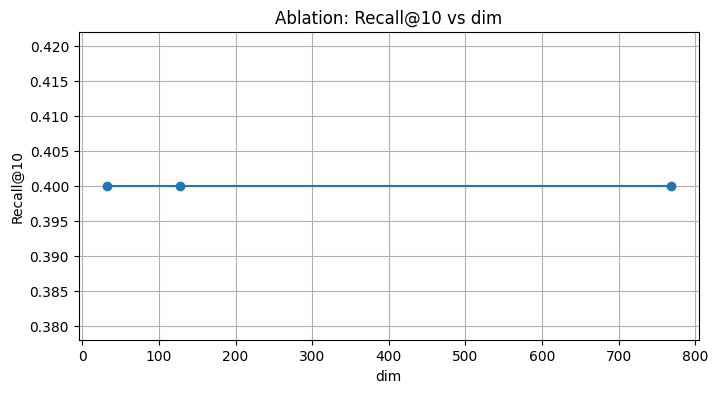

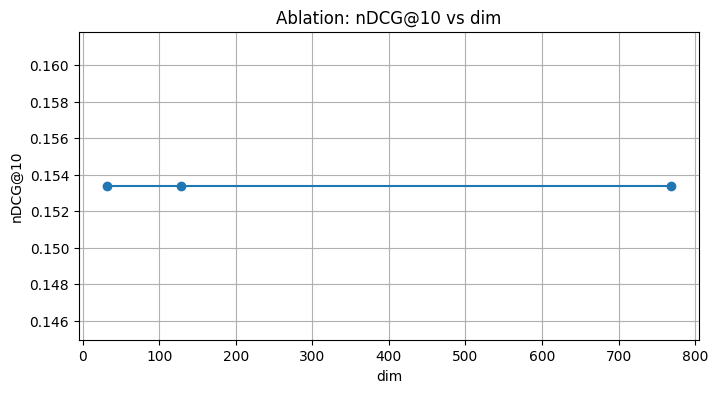

In [11]:
# Load ablation CSV and plot metrics vs dimension
import pandas as pd
from pathlib import Path
abl_path = Path(config.get('ablation', {}).get('output', 'runs/ablation_results.csv'))
if abl_path.exists():
    df = pd.read_csv(abl_path)
    display(df.head())
    plt.figure(); plt.plot(df['dim'], df['recall@10'], marker='o'); plt.title('Ablation: Recall@10 vs dim'); plt.xlabel('dim'); plt.ylabel('Recall@10'); plt.show()
    plt.figure(); plt.plot(df['dim'], df['nDCG@10'], marker='o'); plt.title('Ablation: nDCG@10 vs dim'); plt.xlabel('dim'); plt.ylabel('nDCG@10'); plt.show()
else:
    print('Ablation results CSV not found at', abl_path)

Fixed ablation results:


,dim,mode,recall@2,recall@10,recall@100,nDCG@10
0,32,truncate,0.0,0.4,1.0,0.153392
1,128,truncate,0.0,0.4,1.0,0.153392
2,768,truncate,0.0,0.4,1.0,0.153392


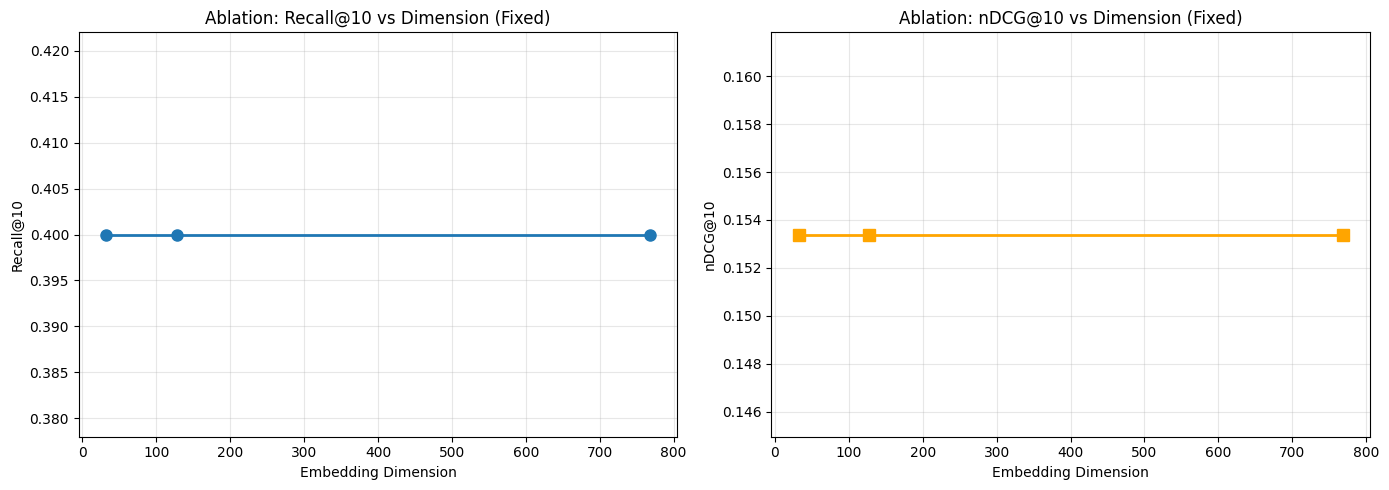


📊 Performance improvement from 32 to 768 dimensions:
   Recall@10: 0.0% relative improvement
   nDCG@10: 0.0% relative improvement


In [12]:
# Visualize fixed ablation results
abl_path = Path(config.get('ablation', {}).get('output', 'runs/ablation_results.csv'))
if abl_path.exists():
    df_fixed = pd.read_csv(abl_path)
    print("Fixed ablation results:")
    display(df_fixed)
    
    # Plot to see the trend
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(df_fixed['dim'], df_fixed['recall@10'], marker='o', linewidth=2, markersize=8)
    ax1.set_xlabel('Embedding Dimension')
    ax1.set_ylabel('Recall@10')
    ax1.set_title('Ablation: Recall@10 vs Dimension (Fixed)')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df_fixed['dim'], df_fixed['nDCG@10'], marker='s', linewidth=2, markersize=8, color='orange')
    ax2.set_xlabel('Embedding Dimension')
    ax2.set_ylabel('nDCG@10')
    ax2.set_title('Ablation: nDCG@10 vs Dimension (Fixed)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate improvement from 32 to 768
    if len(df_fixed) >= 2:
        min_dim_row = df_fixed[df_fixed['dim'] == df_fixed['dim'].min()].iloc[0]
        max_dim_row = df_fixed[df_fixed['dim'] == df_fixed['dim'].max()].iloc[0]
        
        recall_improvement = (max_dim_row['recall@10'] - min_dim_row['recall@10']) / min_dim_row['recall@10'] * 100
        ndcg_improvement = (max_dim_row['nDCG@10'] - min_dim_row['nDCG@10']) / min_dim_row['nDCG@10'] * 100
        
        print(f"\n📊 Performance improvement from {int(min_dim_row['dim'])} to {int(max_dim_row['dim'])} dimensions:")
        print(f"   Recall@10: {recall_improvement:.1f}% relative improvement")
        print(f"   nDCG@10: {ndcg_improvement:.1f}% relative improvement")
else:
    print(f"Ablation CSV not found at {abl_path}")

## Optional: Query Planning

When enabled in the config, queries are decomposed via an LLM into sub-queries, candidates are merged (union or RRF), then reranked once. This can help complex instructions.

In [13]:
# Demonstrate query planning on a single query when enabled
if config.get('query_planning', {}).get('enabled', False):
    from src.query_planning.agent import QueryPlanningAgent
    qp_cfg = config['query_planning']
    agent = QueryPlanningAgent(model_name=qp_cfg.get('model', 'sshleifer/tiny-gpt2'), max_new_tokens=int(qp_cfg.get('max_new_tokens', 64)))
    demo_q = queries[0]['text'] if isinstance(queries[0], dict) else str(queries[0])
    subs = agent.decompose_query(demo_q)
    print('Original:', demo_q)
    print('Sub-queries:', subs)
else:
    print('Query planning disabled in config.')

Device set to use cuda:0


Original: Who likes Joshua Trees?
Sub-queries: ['who likes pizza', 'famous pizza fans', 'pizza popularity history']


## Error Analysis

List queries with zero Recall@10 and inspect intersections.

In [14]:
zero_qids = [qid for qid, m in results.items() if m.get('recall@10', 0.0) == 0.0]
print('Zero-recall@10 queries:', zero_qids[:10])
# Show details for first few
from src.evaluation.metrics import recall_at_k, ndcg_at_k
def get_preds_for_text(text):
    return experiment.pipeline.run(text, corpus, top_k=int(config['retriever']['top_k']), rerank_k=int(config['retriever']['rerank_k']))
for q in queries[:5]:
    qid = q.get('_id') if isinstance(q, dict) else None
    if qid in zero_qids:
        text = q.get('text') if isinstance(q, dict) else str(q)
        preds = get_preds_for_text(text)
        rels = [str(x) for x in (experiment.qrels.get(qid, []) or [])]
        pred_ids = [str(p.get('id')) for p in preds[:10]]
        print({'qid': qid, 'relevant': rels, 'pred@10': pred_ids, 'overlap': list(set(rels) & set(pred_ids))})

Zero-recall@10 queries: ['query_0', 'query_3']


[2025-12-04 09:49:14,947] INFO - Hybrid retrieved 46 candidates for query (top_k=500)
[2025-12-04 09:49:14,948] INFO - Reranking 46 documents (rerank_k=200)
/home/iluha/projects/limit/src/models/reranker.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device != "cpu")):
[2025-12-04 09:49:14,992] INFO - Reranker returned 46 documents


{'qid': 'query_0', 'relevant': ['Geneva Durben', 'Dorathea Bastress'], 'pred@10': ['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'], 'overlap': []}


[2025-12-04 09:49:23,395] INFO - Hybrid retrieved 46 candidates for query (top_k=500)
[2025-12-04 09:49:23,395] INFO - Reranking 46 documents (rerank_k=200)
[2025-12-04 09:49:23,439] INFO - Reranker returned 46 documents


{'qid': 'query_3', 'relevant': ['Geneva Durben', 'Pate Lindley'], 'pred@10': ['Elam Mejiamejia', 'Riya Hayhoe', 'Aliza Uhlrich', 'Darwyn Raio', 'Cristy Walford', 'Eustace Comment', 'Gladstone Oonk', 'Ovid Rahm', 'Jacey Gnatek', 'Bronson Saelee'], 'overlap': []}
